# Imports

In [1]:
import os
import sys

In [2]:
current_dir =  os.getcwd()
# replace this following line in the path your frank2d files are.
parent_dir = os.path.abspath(os.path.join(current_dir, os.pardir))
sys.path.append(parent_dir)

In [3]:
parent_dir

'/localhome/home/zgdz996/frank2d'

In [4]:
import cupy as cp
import matplotlib.pyplot as plt
import time

In [5]:
#frank2d
from frank2d_gpu.frank2d_gpu import Frank2D
from frank2d_gpu.geometry import Geometry
from frank2d_gpu.fourier2d_gpu import FourierTransform2D
from frank2d_gpu.process_vis_gpu import Gridding
from frank2d_gpu.plot_gpu import Plot
from frank2d_gpu.constants import rad_to_arcsec, deg_to_rad
from frank2d_gpu.posterior_optimization_gpu import MAPEstimator

In [6]:

dir = "./../../data/uvtable/"
data_file = dir + "uvtable_SimulatedBlob.txt"
inc = 0
pa = 0
dra = 0
ddec = 0
rout = 1

# Load data
file = cp.loadtxt(data_file, unpack=True)
u, v, Re, Im, Weights = file
Vis = Re + Im*1j
uvtable = {'u': u, 'v': v, 'vis': Vis, 'weights': Weights }

geom = Geometry(inc, pa, dra, ddec)

In [7]:
q = cp.hypot(uvtable['u'], uvtable['v'])
q_min = cp.min(q)
q_max = cp.max(q)

Rmax = 3*rout
import math 
N = math.floor(5* Rmax/rad_to_arcsec * q_max)

print("N =", N)
print("Rmax =", Rmax)

N = 642
Rmax = 3


### frank2d

In [8]:
N_opt = [100]

In [9]:
maps = []
frank2d_objects = []
Qmaxs = []

In [10]:
times_opt =  [] # min
times_best = [] # seg

## Run

In [18]:
maps

[]

In [19]:

for i in N_opt:
    start_time = time.time()
    frank2d = Frank2D(N, Rmax)
    frank2d.process_vis(uvtable)
    initial_guess = {'m': -1, 'logl': 4, 'p':-1}
    frank2d.search_MAP(initial_guess= initial_guess, N = i)

    end_time = time.time()
    total_time = (end_time - start_time)/60
    print("     ---> N = {}, Time taken: {:.2f} mins".format(i, total_time))
    frank2d_objects.append(frank2d)
    times_opt.append(total_time)

    best = frank2d.MAP
    maps.append(best)
    print("     ---> MAP: "+ str(best))

    MAPEs = frank2d.MAPEstimator

    print("     ---> Saving  frank2d object...")
    import pickle
    with open(dir+ disc+'_optCPU_Nopt{}.pkl'.format(i), 'wb') as f:
        pickle.dump(frank2d, f)

    GP =  MAPEs.GaussianModel
    DFT = GP.DFT2
    qmax = cp.max(DFT.Qmax)
    Qmaxs.append(qmax)

    print("     ---> Qmax: " + str(qmax))
    print("x-------------------------------------------------x")

===>  Setting gridded data...
Using existing visibility data...
===>  Searching for MAP parameters...
        + Initial guess:  {'m': -1, 'logl': 4, 'p': -1}
Fitting the visibilities with Frank2D with 2DFT...
 + Time to preprocess the visibilities: 337.58 seconds
Setting the initial guess...
Optimizing the posterior...


In [1]:
print(N_opt)
print("Times taken: ", times_opt)
print("MAPs: ", maps)
print("Qmax: ", Qmaxs)

NameError: name 'N_opt' is not defined

### Save

In [14]:
import pickle
dir_ = "../../data/exp/N_opt/"
for i in range(len(N_opt)):
    print("     ---> Saving  frank2d object...")
    #import pickle
    with open(dir_+'SimulatedBlob_optGPU_Nopt{}.pkl'.format(N_opt[i]), 'wb') as f:
        frank2d = frank2d_objects[i]
        pickle.dump(frank2d, f)

     ---> Saving  frank2d object...


## Upload objects

In [11]:
#upload the .pkl frank objects and inyect them in the array

import pickle

dir = "../../data/exp/N_opt/"

for i in N_opt:
    path = dir + 'SimulatedBlob_optGPU_Nopt' + str(i) + '.pkl'
    with open(path , 'rb') as f:   # 'rb' = read binary
        f2d = pickle.load(f)
        frank2d_objects.append(f2d)

In [12]:
for i in frank2d_objects:
    print(i.MAP)
    maps.append(i.MAP)
    Qmaxs.append(i.MAPEstimator.GaussianModel.DFT2.Qmax)
    print(i.MAPEstimator.GaussianModel.DFT2.Qmax)

{'m': -2.935871997869595, 'c': 79462641420506.69, 'l': 45256.85503754103}
2430854.0536241867


## Let's review the power spectrum

In [13]:
import numpy as np

In [14]:
# Plot visibilities gridded.
from frank.utilities import UVDataBinner       
bin_widths=[1e3, 1e5]

u, v = u.get(), v.get()
Vis, Weights = Vis.get(), Weights.get()

baselines = np.hypot(u, v)
binned_vis = UVDataBinner(baselines, Vis, Weights, bin_widths[0])
x1 = binned_vis.uv
y1 = np.abs(binned_vis.V)**2
logx = np.log10(x1)
logy = np.log10(y1)

binned_vis2 = UVDataBinner(baselines, Vis, Weights, bin_widths[1])
x2 = binned_vis2.uv
y2 = np.abs(binned_vis2.V)**2
logx2 = np.log10(x2)
logy2 = np.log10(y2)

def linear_power_spectrum(logx, m, c):
    return m*logx + np.log10(c)

def power_spectrum(x, m, c):
    return c*x**(m)

x = np.geomspace(np.sort(baselines)[1], baselines.max(), 1000)
lgx = np.log10(x)

y_fits = []
for i in range(len(N_opt)):
    y_fits.append(power_spectrum(x, maps[i]['m'], maps[i]['c']))

cs, ms = ['#a4a4a4', 'k'], ['.', 'x']

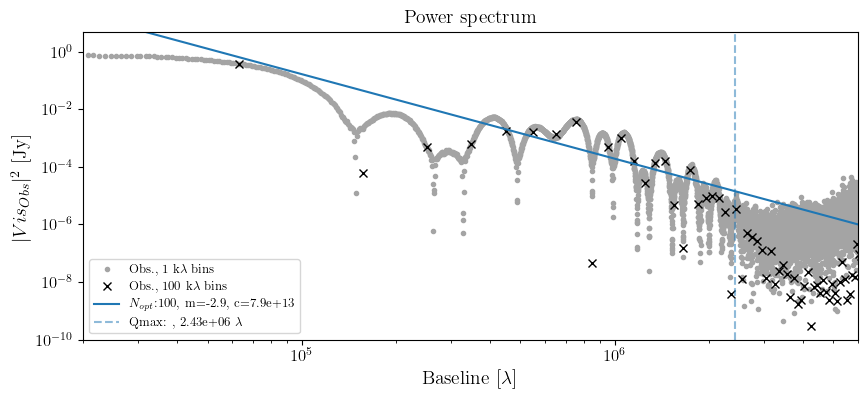

In [15]:
plt.figure(figsize=(10, 4))
plt.plot(x1, y1, c=cs[0], marker=ms[0], ls='None', label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[0]/1e3))
plt.plot(x2, y2, c=cs[1], marker=ms[1], ls='None', label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[1]/1e3))

for i in range(len(N_opt)):
    plt.plot(x, y_fits[i], label=r'$N_{opt}$:' + str(N_opt[i]) + ', m={:.1f}, c={:.1e}'.format(maps[i]['m'], maps[i]['c']), color='C{}'.format(i))
    plt.axvline(Qmaxs[i].get(), ls='--', color='C{}'.format(i), alpha=0.5, label=r'Qmax: '+ ', {:.2e} $\lambda$'.format(Qmaxs[i].get()))

plt.xlabel(r'Baseline [$\lambda$]', size = 14)
plt.ylabel(r'$|Vis_{Obs}|^{2}$ [Jy]', size = 14)
plt.xscale('log')
plt.yscale('log')
plt.legend(loc = 'best', fontsize = 9)
plt.title("Power spectrum", size = 14)
plt.tick_params(axis='both', labelsize=12)
plt.ylim(1e-10, 5)
plt.xlim(2e4, 6e6)
plt.show()

## Time related

### frank2d with best values

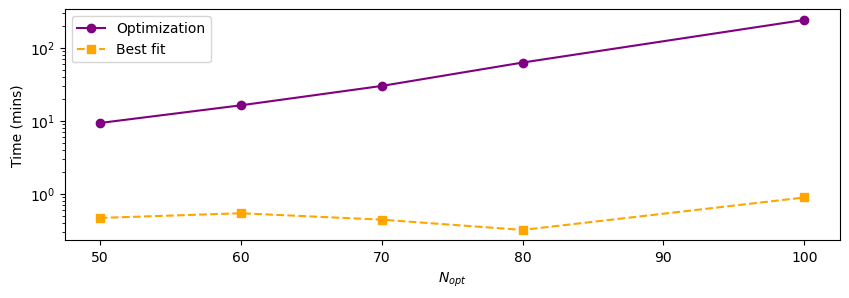

In [75]:
plt.figure(figsize=(10, 3))
plt.plot(N_opt, np.array(times_opt), 'o-', color='purple', label='Optimization')
plt.plot(N_opt, np.array(times_best)/60, 's--', color='orange', label='Best fit')
plt.xlabel(r'$N_{opt}$')
plt.ylabel("Time (mins)")
plt.yscale('log')
plt.legend()
plt.show()

In [14]:
maps

[{'m': -1.7118115146053943, 'c': 1107386.7020548182, 'l': 21833.50491835495},
 {'m': -1.7900507315194405, 'c': 4208615.485734088, 'l': 22746.607839035685},
 {'m': -2.205758019904303, 'c': 1360404752.1630862, 'l': 22817.1219726599},
 {'m': -2.9537030067142087, 'c': 40546491180778.625, 'l': 22781.422417760932},
 {'m': -3.7041542492704664,
  'c': 1.3882769163865464e+18,
  'l': 22906.177349190206}]

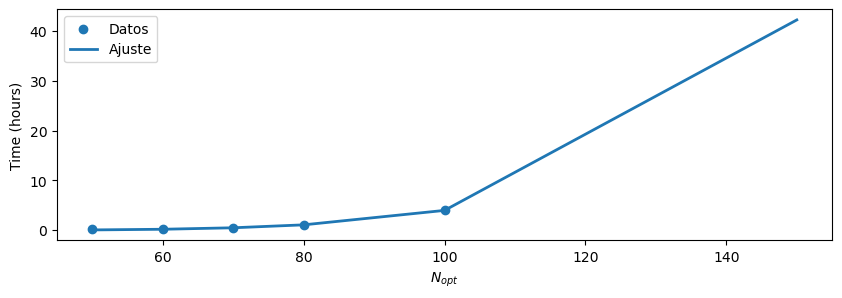

In [90]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

x , y = np.array([50, 60, 70, 80, 100]), np.array(times_opt)
x2 = np.array([50, 60, 70, 80, 100, 150])

# Modelo
def modelo(x, a, b):
    return b*x**a

# Ajuste
params, covariance = curve_fit(modelo, x, y)

a, b = params

# Graficar
plt.figure(figsize=(10, 3))
plt.scatter(x, y/60, label="Datos")
plt.plot(x2, modelo(x2, a, b)/60, label="Ajuste", linewidth=2)
plt.xlabel(r'$N_{opt}$')
plt.ylabel("Time (hours)")
plt.legend()
plt.show()

## Plot the stats for posterior

#### function to plot

In [15]:
import numpy as np

In [18]:
import matplotlib.pyplot as plt
import numpy as np

def plot_MAP_estimation_results(results, results_best, N_opt, normalize=False):
    # 1. Extracción de datos
    ms = np.array(results['ms'])
    cs = np.array(results['cs'])
    ls = np.array(results['ls'])
    
    # Valores "Best" (que actúan como mu en la resta)
    m_best = results_best['m']
    c_best = 10**results_best['logc']
    l_best = 10**results_best['logl']

    fig, axs = plt.subplots(3, 3, figsize=(12, 9), constrained_layout=True)
    axs = axs.ravel()
    iterations = np.arange(1, len(ms) + 1)

    def plot_trace(ax, data, best_val, color, ylabel, label_legend, title=None, use_log_y=False, is_metric=False):
        """
        label_legend: Texto para la leyenda (ej: 'm_best = ...')
        is_metric: Define si se aplica la normalización (x - mu)
        """
        y_data = np.array(data)
        
        if normalize and is_metric:
            y_data = np.abs(y_data - best_val)
            
            label_y = r'$\| x - \mu \|$' 
            ax.set_ylabel(label_y, size=16)

        else:
            ax.axhline(best_val, color='gray', linestyle='--', label=label_legend, alpha=0.7)
            ax.set_ylabel(ylabel, size=16)
            
            ax.legend(fontsize=16, loc='best')
        

        # Ploteo de la traza
        ax.plot(iterations, y_data, '-', c=color, alpha=0.8)
        
        # Estilos comunes
        ax.set_xlabel('Iteration', size=16)
        if title: 
            ax.set_title(title, size=16)
        
        #set grid
        ax.grid(visible=True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
            
        # Ticks tamaño 12
        ax.tick_params(axis='both', which='major', labelsize=14)
        
        # Escala Logarítmica
        if use_log_y:
            try:
                ax.set_yscale('log')
            except:
                pass

    # --- FILA 1: Parámetros (No se normalizan) ---
    
    # m
    label_m = r'$m_{best}$ =' + f'{m_best:.2e}'
    plot_trace(axs[0], ms, m_best, 'purple', 'm', label_m)

    # c
    label_c = r'$c_{best}$ =' + f'{c_best:.2e}'
    plot_trace(axs[1], cs, c_best, 'purple', 'c', label_c, use_log_y=True)

    # l
    label_l = r'$\ell_{best}$ =' + f'{l_best:.2e}'
    plot_trace(axs[2], ls, l_best, 'purple', r'$\ell$', label_l, use_log_y=True)


    # --- FILAS 2 y 3: Métricas (Se normalizan si normalize=True) ---
    
    # jDj
    label_jDj = r'$j^{T}Dj_{best}$ =' + f'{results_best["jDj"]:.2e}'
    plot_trace(axs[3], results['jDjs'], results_best['jDj'], 'red', 
               'jDj', label_jDj, title=r'$j^{T}Dj$', 
               use_log_y=True, is_metric=True)

    # log|D| (Barra simple)
    label_ldD = r'log$|D|_{best}$ =' + f'{results_best["logdetD"]:.2e}'
    plot_trace(axs[4], results['logdetDs'], results_best['logdetD'], 'blue', 
               r'log$|D|$', label_ldD, title=r'log$|D|$', 
               use_log_y=True, is_metric=True)

    # log|S| (Barra simple)
    label_ldS = r'log$|S|_{best}$ =' + f'{results_best["logdetS"]:.2e}'
    plot_trace(axs[5], results['logdetSs'], results_best['logdetS'], 'green', 
               r'log$|S|$', label_ldS, title=r'log$|S|$', 
               use_log_y=True, is_metric=True) 

    # -logP
    label_logP = r'$-logP_{best}$ =' + f'{results_best["minus_log_posterior"]:.2e}'
    plot_trace(axs[7], results['minus_log_posteriors'], results_best['minus_log_posterior'], 'black', 
               '-logP', label_logP, title=r'-logP($\theta | V$)', 
               use_log_y=True, is_metric=True)


    # --- LIMPIEZA FINAL ---
    for ax in [axs[6], axs[8]]:
        ax.axis('off')

    fig.suptitle(r'MAP Estimation $N_{opt}$ = ' + str(N_opt), fontsize=16)
    plt.show()

In [19]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "text.latex.preamble": r"\usepackage{bm}", # Recomendado para negritas matemáticas
})

#### run them all

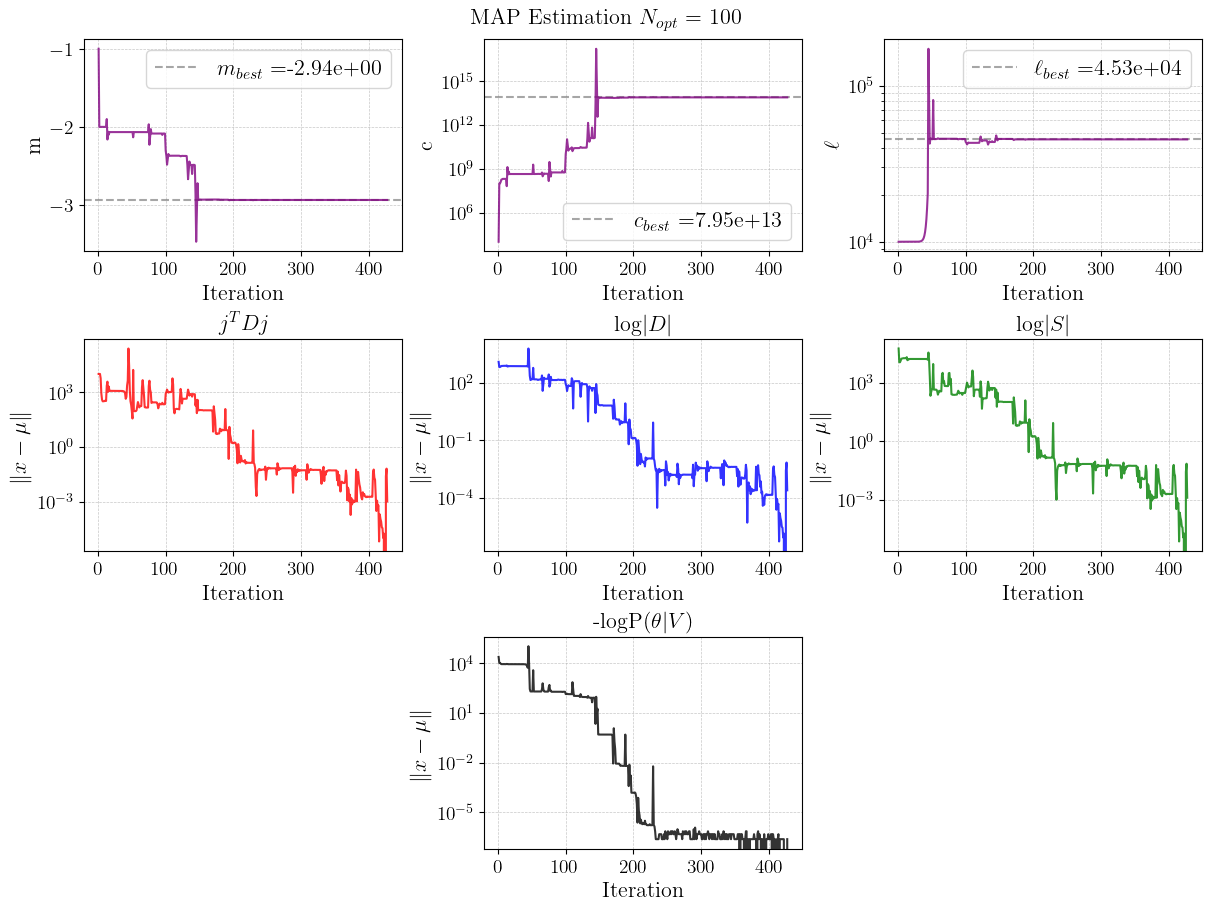

In [20]:
for i in range(0, len(N_opt)):
    frank2d_N = frank2d_objects[i]
    MAPEs_N = frank2d_N.MAPEstimator

    MAP_N = frank2d_N.MAP
    m_best_N = MAP_N['m']
    l_best_N = MAP_N['l']
    c_best_N = MAP_N['c']
    logl_best_N = np.log10(l_best_N)
    logc_best_N = np.log10(c_best_N)
    best_N = {
        'm': m_best_N,
        'logl': logl_best_N,
        'logc': logc_best_N
    }

    ms_N =  MAPEs_N._ms
    cs_N = MAPEs_N._cs
    ls_N = MAPEs_N._ls
    jDjs_N = MAPEs_N._jDjs
    logdetDs_N = MAPEs_N._logdetDs
    logdetSs_N = MAPEs_N._logdetSs
    minus_log_posteriors_N = MAPEs_N._minus_log_posteriors

    results_N = {
        'ms': ms_N,
        'cs': cs_N,
        'ls': ls_N,
        'jDjs': jDjs_N,
        'logdetDs': logdetDs_N,
        'logdetSs': logdetSs_N,
        'minus_log_posteriors': minus_log_posteriors_N,
    }

    GP_N =  MAPEs_N.GaussianModel
    p0, jDj0, logdetS0, logdetD0 = MAPEs_N._p0
    best_minus_log_posteriors_N = GP_N.minus_log_posterior(best_N) -p0
    best_jDj_N, best_logdetD_N, best_logdetS_N = GP_N._jDj - jDj0, GP_N._logdetD-logdetD0, GP_N._logdetS-logdetS0
    
    results_best_N = {
        'm': m_best_N,
        'logl': logl_best_N,
        'logc': logc_best_N,
        'minus_log_posterior': best_minus_log_posteriors_N,
        'jDj': best_jDj_N,
        'logdetD': best_logdetD_N,
        'logdetS': best_logdetS_N,
    }

    plot_MAP_estimation_results(results_N, results_best_N, N_opt[i], normalize = True) 


### Maximum baseline for each N_opt

In [19]:
for i in range(0, len(N_opt)):
    frank2d_N = frank2d_objects[i]
    MAPEs_N = frank2d_N.MAPEstimator
    GP_N =  MAPEs_N.GaussianModel
    DFT_N = GP_N._2DFT
    print( DFT_N.Qmax)


2430854.0536241867


In [26]:
l_array = []
for i in maps:
    l_array.append(i['l'])

In [34]:
mis_colores = ['C0', 'C1', 'C2', 'C3']

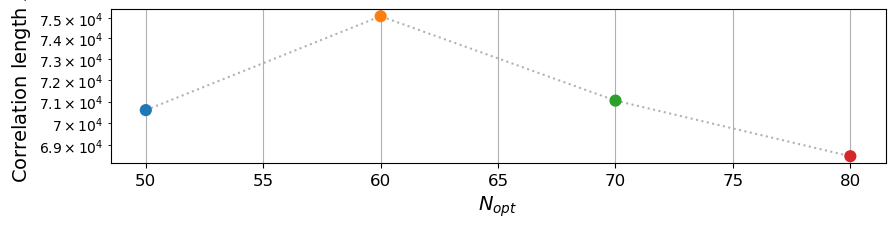

In [63]:
plt.figure(figsize=(10,2))

plt.plot(N_opt, l_array, ':', color='black', alpha=0.3, zorder=1)
plt.scatter(N_opt, l_array, c=mis_colores, s=60, zorder=2)
plt.yscale('log')
plt.xlabel(r'$N_{opt}$', size=14)
plt.ylabel(r'Correlation length $\ell$', size=14)
plt.tick_params(axis='both', labelsize=12)
plt.grid()
plt.show()


In [65]:
p = -1
m = -1
logc = p - 5*m


SyntaxError: invalid syntax. Maybe you meant '==' or ':=' instead of '='? (2249569240.py, line 1)

## Plot the best

In [39]:
times_best2 = []

In [40]:
frank2d_objects_best = []

In [41]:
for i in range(len(frank2d_objects)):
    start = time.time()
    frank2d = Frank2D(N, Rmax)
    maps_i = maps[i]
    frank2d.fit(data = uvtable, kernel_params = maps_i, rtol = 1e-10)

    end = time.time()
    total_time = end - start
    times_best2.append(total_time)
    frank2d_objects_best.append(frank2d)
    print(f"xxxxxxxxxxxxxxxxxxxxxxxxx F2D with maps ={maps_i} took {end - start} seconds xxxxxxxxxxxxxxxxxxxxxxxxxxxx")


===>  Setting gridded data...
===>  Setting GP Kernel wend...
        + Kernel parameters:  {'m': -2.172575106040783, 'c': 2227255625.75811, 'l': 70600.24789788261}
===>  Creating sparse linear system...
        + time kernel = 0.01  min |  0.67 seconds
        + Using preconditioner method:  jacobi
        + time building system = 0.01  min |  0.84 seconds
===>  Solving linear system...
         + maxiter =  50000  & rtol =  1e-10
         + final tolerance :  0.0


         + Fitting with BiCGStab...:   0%|          | 199/50000 [00:10<44:53, 18.49 iterations/s]


            --> times solving system = 0.18  min |  11.09 seconds
          + CGM converged?   True
          + Fit correctly?    ✔✔✔✔✔✔✔ CGM Sucess..
Building full visibility model...
--> times building full visibility model = 0.02  min |  1.10 seconds
xxxxxxxxxxxxxxxxxxxxxxxxx F2D with maps ={'m': -2.172575106040783, 'c': 2227255625.75811, 'l': 70600.24789788261} took 13.53720736503601 seconds xxxxxxxxxxxxxxxxxxxxxxxxxxxx
===>  Setting gridded data...
===>  Setting GP Kernel wend...
        + Kernel parameters:  {'m': -2.6356759886206267, 'c': 1396195494012.863, 'l': 75086.59037624154}
===>  Creating sparse linear system...
        + time kernel = 0.01  min |  0.61 seconds
        + Using preconditioner method:  jacobi
        + time building system = 0.01  min |  0.61 seconds
===>  Solving linear system...
         + maxiter =  50000  & rtol =  1e-10
         + final tolerance :  0.0


         + Fitting with BiCGStab...:   1%|          | 261/50000 [00:13<44:22, 18.68 iterations/s]


            --> times solving system = 0.23  min |  13.97 seconds
          + CGM converged?   True
          + Fit correctly?    ✔✔✔✔✔✔✔ CGM Sucess..
Building full visibility model...
--> times building full visibility model = 0.02  min |  1.13 seconds
xxxxxxxxxxxxxxxxxxxxxxxxx F2D with maps ={'m': -2.6356759886206267, 'c': 1396195494012.863, 'l': 75086.59037624154} took 16.091917991638184 seconds xxxxxxxxxxxxxxxxxxxxxxxxxxxx
===>  Setting gridded data...
===>  Setting GP Kernel wend...
        + Kernel parameters:  {'m': -2.96906055182971, 'c': 121781113253450.83, 'l': 71042.33070708397}
===>  Creating sparse linear system...
        + time kernel = 0.01  min |  0.55 seconds
        + Using preconditioner method:  jacobi
        + time building system = 0.01  min |  0.55 seconds
===>  Solving linear system...
         + maxiter =  50000  & rtol =  1e-10
         + final tolerance :  0.0


         + Fitting with BiCGStab...:   1%|          | 283/50000 [00:15<46:01, 18.01 iterations/s]


            --> times solving system = 0.26  min |  15.73 seconds
          + CGM converged?   True
          + Fit correctly?    ✔✔✔✔✔✔✔ CGM Sucess..
Building full visibility model...
--> times building full visibility model = 0.02  min |  1.12 seconds
xxxxxxxxxxxxxxxxxxxxxxxxx F2D with maps ={'m': -2.96906055182971, 'c': 121781113253450.83, 'l': 71042.33070708397} took 17.77356481552124 seconds xxxxxxxxxxxxxxxxxxxxxxxxxxxx
===>  Setting gridded data...
===>  Setting GP Kernel wend...
        + Kernel parameters:  {'m': -3.446351239267294, 'c': 9.29101095435081e+16, 'l': 68496.87161364655}
===>  Creating sparse linear system...
        + time kernel = 0.01  min |  0.53 seconds
        + Using preconditioner method:  jacobi
        + time building system = 0.01  min |  0.53 seconds
===>  Solving linear system...
         + maxiter =  50000  & rtol =  1e-10
         + final tolerance :  0.0


         + Fitting with BiCGStab...:   1%|          | 370/50000 [00:20<46:38, 17.73 iterations/s]


            --> times solving system = 0.35  min |  20.87 seconds
          + CGM converged?   True
          + Fit correctly?    ✔✔✔✔✔✔✔ CGM Sucess..
Building full visibility model...
--> times building full visibility model = 0.03  min |  1.71 seconds
xxxxxxxxxxxxxxxxxxxxxxxxx F2D with maps ={'m': -3.446351239267294, 'c': 9.29101095435081e+16, 'l': 68496.87161364655} took 23.519453525543213 seconds xxxxxxxxxxxxxxxxxxxxxxxxxxxx


In [50]:
for i in range(len(frank2d_objects_best)):
    Plot_ = Plot(frank2d_objects_best[i], geom)
    Plot_.intensity( vmax=5e10,  gamma = 1, zoom=2,
                     title= r'$I_{model}^{frank2d}$ for $N_{opt}$ = ' + str(N_opt[i]))
    Plot_.visibility(fig_size = 6, zoom =2,
                     title = r'$Vis_{model}^{frank2d}$ for $N_{opt}$ = ' + str(N_opt[i]))

TypeError: Plot.intensity() got an unexpected keyword argument 'size_label'

## Review power spectrum

In [ ]:
params_N50, params_N60, params_N70, params_N80, params_N100 = [{'m': -2.692877726304575, 'c': 5565999406071.04, 'l': 85344.27916739318}, {'m': -3.173339346404725, 'c': 4782311642990891.0, 'l': 83515.6290880256}, {'m': -3.5831562281230305, 'c': 1.473704358376612e+18, 'l': 81079.44744259916}, {'m': -4.572442130254884, 'c': 1.0084384650978846e+24, 'l': 68720.771036978}, {'m': -6.0445769086881205, 'c': 1.4300593860064604e+33, 'l': 80200.56804261949}]
Qmax_N50, Qmax_N60, Qmax_N70, Qmax_N80, Qmax_N100 = [1823140.5402181398, 2187768.648261768, 2552396.756305396, 2917024.8643490244, 3646281.0804362795]

# Plot visibilities gridded.
from frank.utilities import UVDataBinner       
bin_widths=[1e3, 1e5]

baselines = np.hypot(u, v)
binned_vis = UVDataBinner(baselines, Vis, Weights, bin_widths[0])
x1 = binned_vis.uv
y1 = np.abs(binned_vis.V)**2
logx = np.log10(x1)
logy = np.log10(y1)

binned_vis2 = UVDataBinner(baselines, Vis, Weights, bin_widths[1])
x2 = binned_vis2.uv
y2 = np.abs(binned_vis2.V)**2
logx2 = np.log10(x2)
logy2 = np.log10(y2)

def linear_power_spectrum(logx, m, c):
    return m*logx + np.log10(c)

def power_spectrum(x, m, c):
    return c*x**(m)

x = np.geomspace(np.sort(baselines)[1], baselines.max(), 1000)
lgx = np.log10(x)

y_N50 = power_spectrum(x, params_N50['m'], params_N50['c'])
y_N60 = power_spectrum(x, params_N60['m'], params_N60['c'])
y_N70 = power_spectrum(x, params_N70['m'], params_N70['c'])
y_N80 = power_spectrum(x, params_N80['m'], params_N80['c'])
y_N100 = power_spectrum(x, params_N100['m'], params_N100['c'])

cs, ms = ['#a4a4a4', 'k'], ['.', 'x']


In [ ]:

plt.figure(figsize=(10, 3))
plt.plot(x1, y1, c=cs[0], marker=ms[0], ls='None', label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[0]/1e3))
plt.plot(x2, y2, c=cs[1], marker=ms[1], ls='None', label=r'Obs., {:.0f} k$\lambda$ bins'.format(bin_widths[1]/1e3))

plt.plot(x, y_N50, c = 'r', label=r'$N_{opt}$=50,'+ 'm={:.1f}, c={:.1e}'.format(params_N50['m'], params_N50['c']))
plt.plot(x, y_N60, c = 'orange', label=r'$N_{opt}$=60,'+ 'm={:.1f}, c={:.1e}'.format(params_N60['m'], params_N60['c']))
plt.plot(x, y_N70, c='g', label=r'$N_{opt}$=70,'+ ' m={:.1f}, c={:.1e}'.format(params_N70['m'], params_N70['c']))
plt.plot(x, y_N80, c='b', label=r'$N_{opt}$=80,'+ ' m={:.1f}, c={:.1e}'.format(params_N80['m'], params_N80['c']))
plt.plot(x, y_N100, c='purple', label=r'$N_{opt}$=100,'+ ' m={:.1f}, c={:.1e}'.format(params_N100['m'], params_N100['c']))

plt.axvline(Qmax_N50, color='r', ls=':', label=r'$Q_{max}$ $N_{opt}$=50')
plt.axvline(Qmax_N60, color='orange', ls=':')
plt.axvline(Qmax_N70, color='g', ls=':')
plt.axvline(Qmax_N80, color='b', ls=':')
plt.axvline(Qmax_N100, color='purple', ls=':')

plt.xlabel(r'log Baseline [$\lambda$]', size = 10)
plt.ylabel(r'log $|Vis_{Obs}|^{2}$ [Jy]', size = 10)
plt.xscale('log')
plt.yscale('log')
plt.legend(loc = 'best', fontsize = 6)
plt.title("Power spectrum")
plt.ylim(1e-12, 2)
plt.xlim(2e4, 6e6)
plt.show()